# Tech Challenge - Fase 1
## Diagnóstico de Câncer de Mama com Machine Learning

Sistema de apoio ao diagnóstico focado em saúde e segurança da mulher, utilizando o
dataset **Breast Cancer Wisconsin (Diagnostic)** para classificar tumores como
**malignos** ou **benignos** a partir de características extraídas de exames de imagem
(punção aspirativa por agulha fina - FNA).

**Dataset:** [Breast Cancer Wisconsin (Diagnostic) - Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data)
(equivalente ao dataset disponibilizado nativamente pelo `scikit-learn`, usado aqui para
garantir reprodutibilidade sem necessidade de download manual).

### Estrutura deste notebook
1. Exploração de dados
2. Pré-processamento
3. Análise de correlação
4. Modelagem (Regressão Logística, Árvore de Decisão, KNN)
5. Treinamento e avaliação (accuracy, recall, F1-score)
6. Explicabilidade (feature importance e SHAP)
7. Discussão crítica dos resultados


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


## 1. Exploração de dados

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

# target: 0 = maligno, 1 = benigno (convenção do sklearn) -> renomeamos para clareza
df["diagnostico"] = df["target"].map({0: "maligno", 1: "benigno"})

print(f"Formato do dataset: {df.shape}")
df.head()


Formato do dataset: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,maligno
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,maligno
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,maligno
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,maligno
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,maligno


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [5]:
print("Valores ausentes por coluna:")
print(df.isna().sum().sum(), "valores ausentes no total")


Valores ausentes por coluna:
0 valores ausentes no total


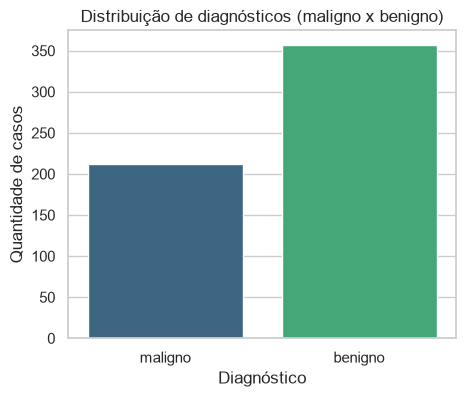

diagnostico
benigno    62.7
maligno    37.3
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="diagnostico", hue="diagnostico", palette="viridis", legend=False)
plt.title("Distribuição de diagnósticos (maligno x benigno)")
plt.xlabel("Diagnóstico")
plt.ylabel("Quantidade de casos")
plt.show()

print(df["diagnostico"].value_counts(normalize=True).round(3) * 100)


**Discussão:** o dataset apresenta um desbalanceamento moderado entre as classes
(mais casos benignos do que malignos), o que reforça a necessidade de usar métricas além
da acurácia (como *recall* e *F1-score*) para avaliar o modelo, já que a classe maligna
(a que mais importa clinicamente detectar) é a minoritária.

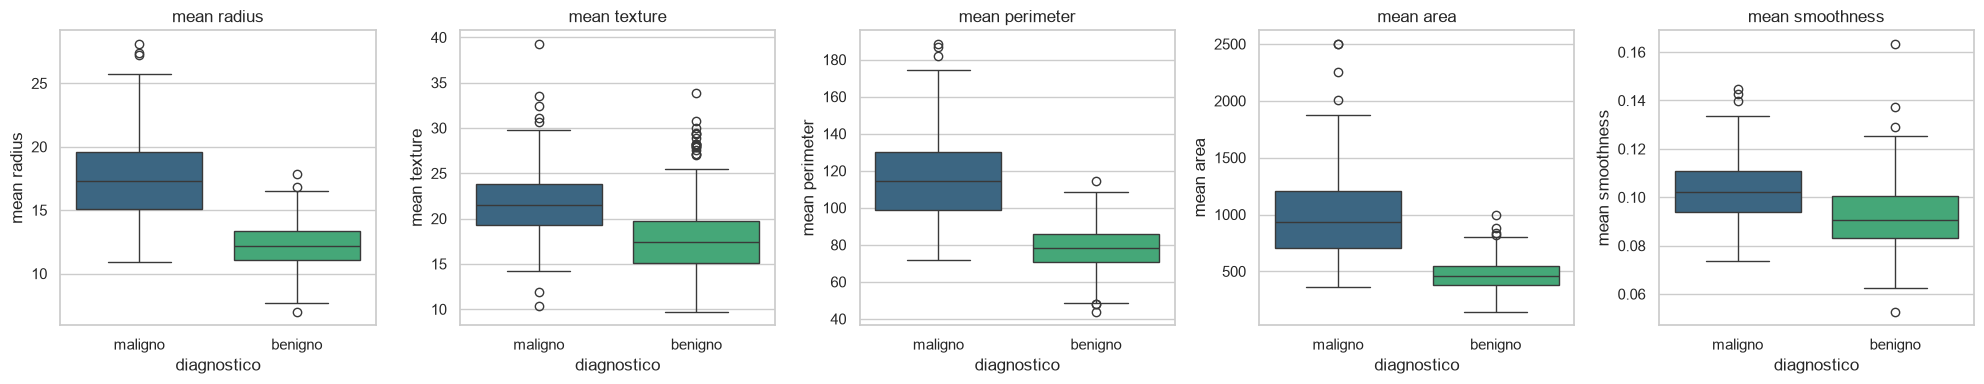

In [7]:
features_exemplo = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness"]

fig, axes = plt.subplots(1, len(features_exemplo), figsize=(20, 4))
for ax, feat in zip(axes, features_exemplo):
    sns.boxplot(data=df, x="diagnostico", y=feat, hue="diagnostico", palette="viridis", legend=False, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()


**Padrões observados:** tumores malignos tendem a apresentar valores maiores de
raio médio, perímetro e área em relação aos benignos, o que é consistente com o
conhecimento clínico de que tumores malignos costumam ser maiores e mais irregulares.

## 2. Pré-processamento de dados

In [8]:
# Não há valores ausentes ou inconsistentes neste dataset (já verificado acima).
# Separação entre variáveis preditoras (X) e variável alvo (y)
X = df[data.feature_names]
y = df["target"]  # 0 = maligno, 1 = benigno

# Todas as variáveis já são numéricas (não há variáveis categóricas a codificar)
print(X.dtypes.unique())


[dtype('float64')]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")


Treino: 455 amostras | Teste: 114 amostras


**Pipeline de pré-processamento:**
1. Verificação de valores ausentes/inconsistentes (nenhum encontrado);
2. Separação treino/teste com estratificação para preservar a proporção de classes;
3. Padronização (`StandardScaler`) das variáveis numéricas, importante para modelos
   sensíveis à escala como Regressão Logística e KNN.

## 3. Análise de correlação

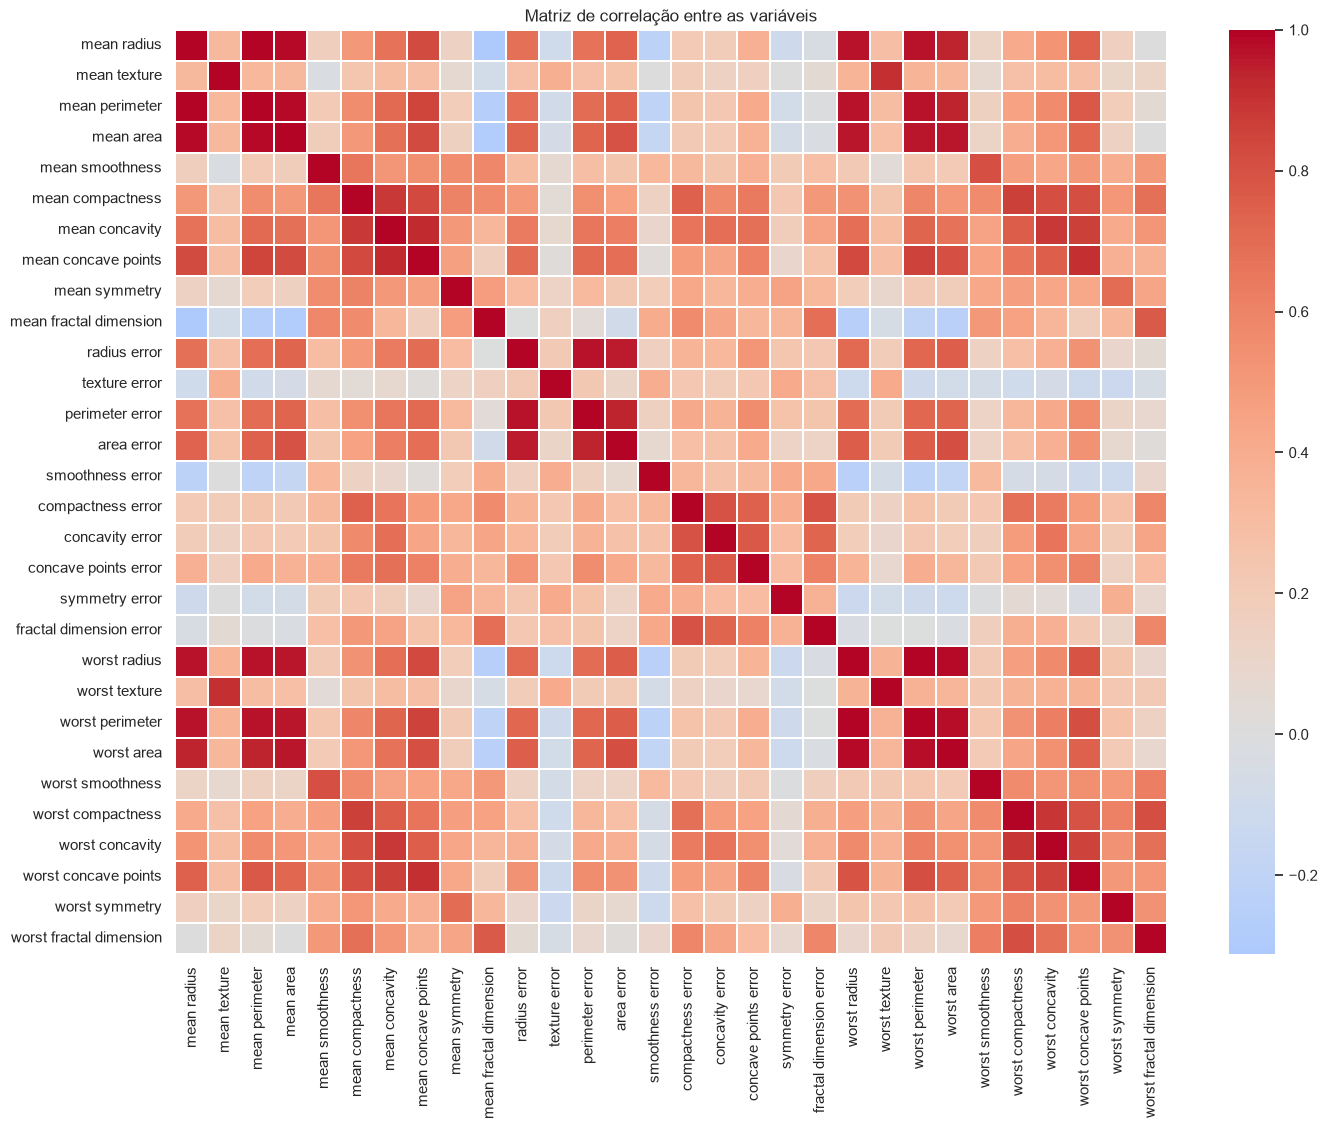

In [10]:
plt.figure(figsize=(16, 12))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Matriz de correlação entre as variáveis")
plt.show()


In [11]:
corr_com_target = df[list(data.feature_names) + ["target"]].corr()["target"].drop("target").sort_values()
print("Variáveis mais correlacionadas com o diagnóstico (target):")
print(corr_com_target.head(5))
print("...")
print(corr_com_target.tail(5))


Variáveis mais correlacionadas com o diagnóstico (target):
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
Name: target, dtype: float64
...
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0.008303
mean fractal dimension     0.012838
smoothness error           0.067016
Name: target, dtype: float64


**Discussão:** há forte correlação entre variáveis relacionadas ao tamanho do tumor
(raio, perímetro, área) — o que é esperado, já que são medidas derivadas umas das
outras. Variáveis como `worst concave points`, `worst perimeter` e `mean concave points`
apresentam a maior correlação (negativa, pois target=0 é maligno) com o diagnóstico,
sugerindo forte poder discriminativo.

## 4. Modelagem

In [12]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Árvore de Decisão": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}


## 5. Treinamento e avaliação do modelo

In [13]:
resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, modelo.predict_proba(X_test_scaled)[:, 1]),
    })

df_resultados = pd.DataFrame(resultados).set_index("Modelo").round(4)
df_resultados


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Modelo,,,,,
Regressão Logística,0.9825,0.9861,0.9861,0.9861,0.9954
Árvore de Decisão,0.9211,0.9565,0.9167,0.9362,0.9163
KNN,0.9561,0.9589,0.9722,0.9655,0.9788


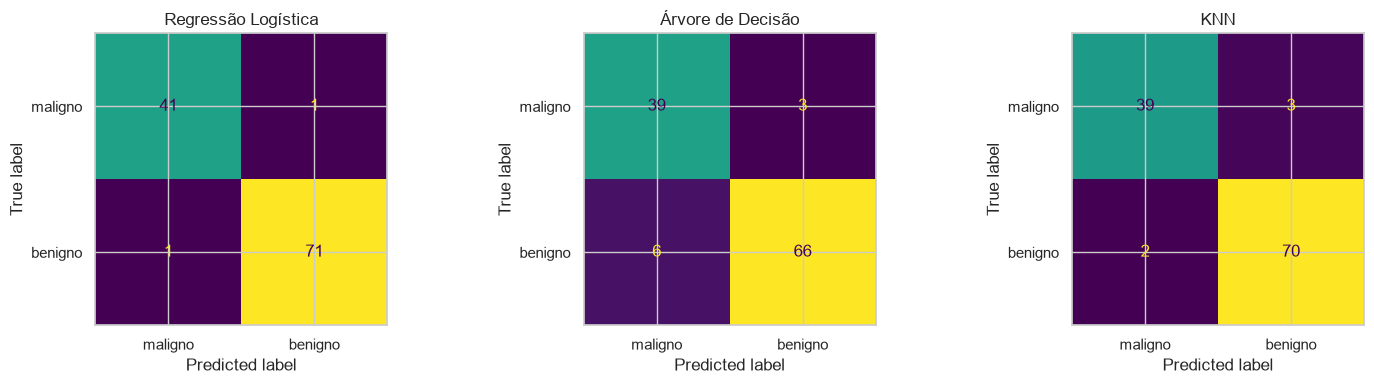

In [14]:
fig, axes = plt.subplots(1, len(modelos), figsize=(15, 4))
for ax, (nome, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["maligno", "benigno"]).plot(ax=ax, colorbar=False)
    ax.set_title(nome)
plt.tight_layout()
plt.show()


In [15]:
for nome, modelo in modelos.items():
    print(f"\n=== {nome} ===")
    y_pred = modelo.predict(X_test_scaled)
    print(classification_report(y_test, y_pred, target_names=["maligno", "benigno"]))



=== Regressão Logística ===
              precision    recall  f1-score   support

     maligno       0.98      0.98      0.98        42
     benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== Árvore de Decisão ===
              precision    recall  f1-score   support

     maligno       0.87      0.93      0.90        42
     benigno       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


=== KNN ===
              precision    recall  f1-score   support

     maligno       0.95      0.93      0.94        42
     benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weigh

**Escolha da métrica:** em um cenário de diagnóstico médico, um **falso negativo**
(dizer que um tumor maligno é benigno) é muito mais grave do que um falso positivo,
pois pode atrasar um tratamento necessário. Por isso, o **recall da classe maligna**
é a métrica mais importante a ser priorizada, junto com o **F1-score**, que equilibra
precisão e recall. A acurácia isolada pode ser enganosa devido ao desbalanceamento
das classes.

## 6. Explicabilidade do modelo

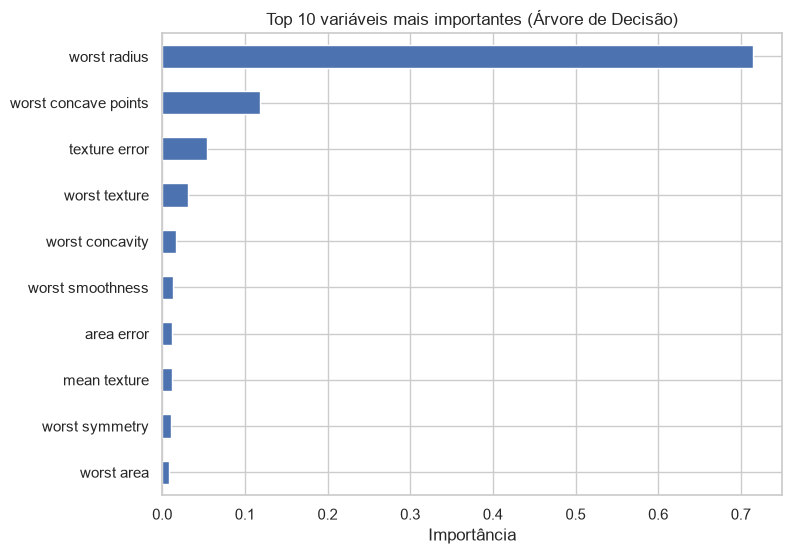

In [16]:
# Feature importance - Árvore de Decisão
arvore = modelos["Árvore de Decisão"]
importancias = pd.Series(arvore.feature_importances_, index=data.feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importancias.head(10).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 10 variáveis mais importantes (Árvore de Decisão)")
plt.xlabel("Importância")
plt.show()


C:\Users\Pichau\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


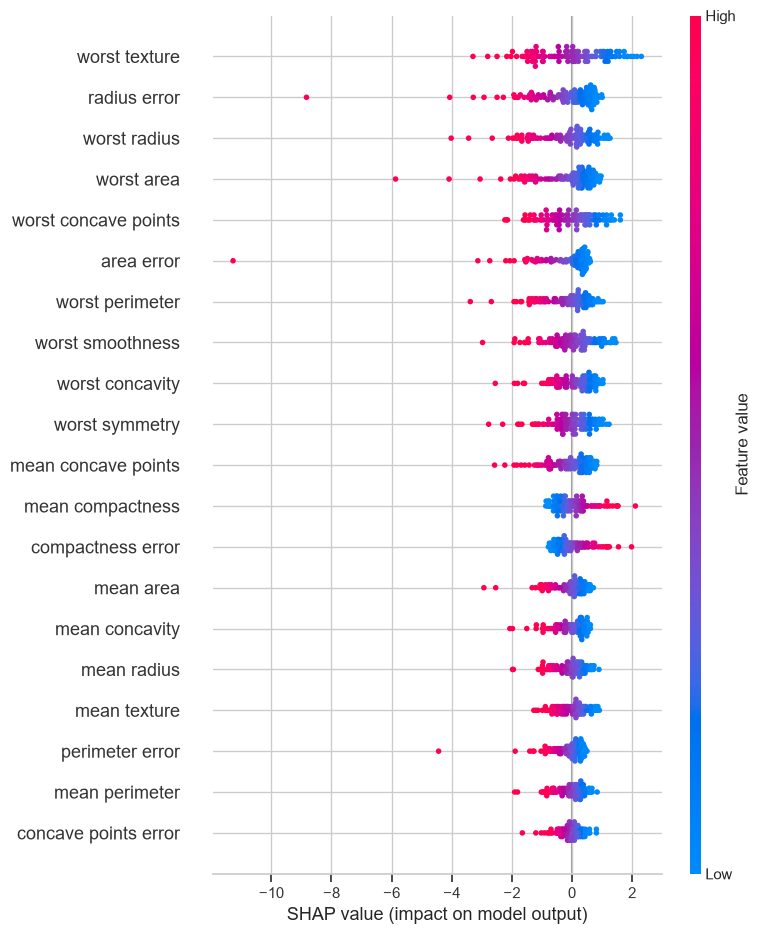

In [17]:
try:
    import shap

    explainer = shap.LinearExplainer(modelos["Regressão Logística"], X_train_scaled)
    shap_values = explainer.shap_values(X_test_scaled)

    shap.summary_plot(
        shap_values, X_test_scaled, feature_names=data.feature_names, show=True
    )
except ImportError:
    print("Biblioteca 'shap' não instalada. Rode: pip install shap")


**Interpretação:** tanto o *feature importance* da árvore de decisão quanto os
valores SHAP da regressão logística apontam variáveis relacionadas à forma e ao tamanho
do tumor (`worst concave points`, `worst area`, `worst radius`, `mean concave points`)
como os principais fatores que influenciam a predição — o que é clinicamente coerente,
já que irregularidade de contorno e tamanho são indicadores conhecidos de malignidade.

## 7. Discussão crítica

O modelo apresentou resultados fortes nas métricas avaliadas, mas é importante
destacar suas limitações antes de qualquer uso prático:

- **Tamanho e origem do dataset:** o conjunto de dados é relativamente pequeno (569
  amostras) e vem de uma única instituição, o que pode limitar a generalização para
  outras populações e equipamentos de exame;
- **Uso responsável:** o modelo pode ser utilizado como uma **ferramenta de apoio à
  triagem**, ajudando a priorizar casos suspeitos para revisão médica mais rápida —
  mas **o médico deve sempre ter a palavra final no diagnóstico**. O sistema não deve
  substituir a avaliação clínica, biópsias ou exames complementares;
- **Próximos passos (fases futuras):** validação com bases de dados maiores e mais
  diversas, testes com dados de imagem (CNN) para mamografias, e avaliação de vieses
  entre diferentes perfis de pacientes.
